# Previous Sessions Analysis

As teams prepare for the upcoming race, they use the most recent data collected through the weekend to try to come up with race strategies and plans. Let's take a look...

## How to evaluate performance?

Most of the teams are not on top of the grid. They fall somewhere along the midfield pack. How do these teams evaluate their performance when they are not able to beat the top teams?

Furthermore, practice sessions do not have positions. So how do we evaluate performance when positions are not taken into consideration?

Most of the time, teams evaluate their pace, that is, their lap time. Achieving good lap times is the fundamental way to win a race, even though good lap times are not everything. For this specific grand prix, the correlation between lap times and position are about 0.80 of 1.

To achieve this, we will use FastF1s `pick_quicklaps` method as it filters only laps within 107% of the fastest lap of the session.

## Environment setup

In [1]:
import os

import fastf1 as ff1
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from fastf1 import plotting
from fastf1.logger import set_log_level

from plots.laps import plot_laptime_correlation_heatmap, plot_team_vs_overall_tyre_wear
from plots.tyres import (
    plot_average_lap_time_by_tyre_wear,
    plot_laptime_distribution_by_team_with_tyre_life,
    plot_tyre_decay_scatter_plot,
)
from processing.laps import get_means_for_laps, get_tyre_life_stats
from tests.distribution import ks_test, mann_whitney_u_test
from tests.normality import plot_normality_visual_inspection, shapiro_wilk_test

load_dotenv()

set_log_level("ERROR")
plotting.setup_mpl(mpl_timedelta_support=True, color_scheme="fastf1")
np.random.seed(123)

TEAM_1 = os.getenv("TEAM_1")
EVENT_YEAR = int(os.getenv("EVENT_YEAR"))
ROUND = int(os.getenv("ROUND"))

%matplotlib widget

## Aggregating and cleaning data

### Aggregating laps data from all previous sessions in the weekend

We will use data from all the other sessions and aggregate them into a single DataFrame.

In [2]:
fp1 = ff1.get_session(EVENT_YEAR, ROUND, "FP1")
sq = ff1.get_session(EVENT_YEAR, ROUND, "SQ")
sprint = ff1.get_session(EVENT_YEAR, ROUND, "S")
quali = ff1.get_session(EVENT_YEAR, ROUND, "Q")
fp1.load()
sq.load()
sprint.load()
quali.load()

In [3]:
fp1_push_laps = fp1.laps.pick_quicklaps()
sq_push_laps = sq.laps.pick_quicklaps()
sprint_push_laps = sprint.laps.pick_quicklaps()
quali_push_laps = quali.laps.pick_quicklaps()

In [4]:
all_laps = pd.concat([
    fp1_push_laps.assign(Session="FP1"),
    sq_push_laps.assign(Session="SQ"),
    sprint_push_laps.assign(Session="Sprint"),
    quali_push_laps.assign(Session="Quali"),
], ignore_index=True)

### Cleaning data and feature engineering

In [5]:
all_laps = all_laps[~all_laps["Deleted"]] # Removing deleted laps, they are invalid

Converting lap times to seconds is very important to allow better calculations.

In [6]:
all_laps["LapTime_s"] = all_laps["LapTime"].dt.total_seconds()

C:\Users\Vitor\AppData\Local\Temp\ipykernel_24540\2692686783.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_laps["LapTime_s"] = all_laps["LapTime"].dt.total_seconds()


In [7]:
# Removing unused featured for easier and lighter calculations
DROP_FEATURES = ["Deleted", "DeletedReason", "FastF1Generated", "LapStartTime",
                 "LapStartDate", "Sector1SessionTime", "Sector2SessionTime",
                 "Sector3SessionTime", "IsPersonalBest", "IsAccurate", "SpeedFL"]
all_laps = all_laps.drop(columns=DROP_FEATURES)

Converting these data to integers is important to calculate correlations.

In [8]:
session_dummies = pd.get_dummies(all_laps.Session, prefix="Session", dtype=int) 
all_laps = pd.concat([all_laps, session_dummies], axis=1)

### Separating data between different tyre compounds

In [9]:
soft = all_laps.pick_compounds("SOFT")
medium = all_laps.pick_compounds("MEDIUM")
hard = all_laps.pick_compounds("HARD")

## Analyzing lap time trends and distribution

### Analyzing general lap time

Firstly, let's take a look at how much time a lap time takes, taking into consideration all of the grid, regardless of session or tyre compound.

In [56]:
print(f"An average lap takes {all_laps.LapTime_s.mean():.3f} +/- {all_laps.LapTime_s.std():.3f}")

An average lap takes 84.157 +/- 2.182


Therefore, mere seconds each lap can determine winners and loses.

Test stastic 0.9068
P-Value 0.0000
The data does NOT look normally distributed.


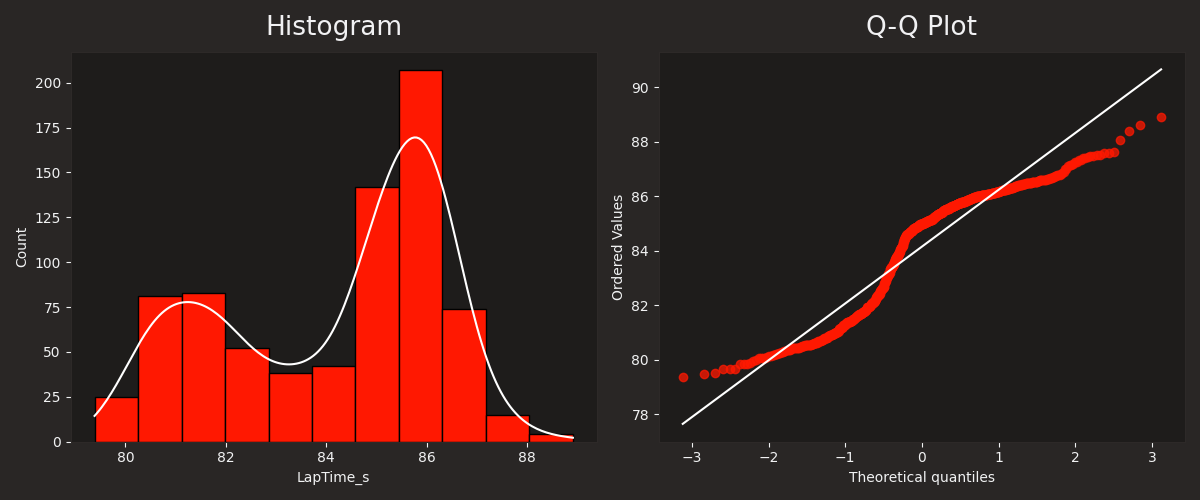

In [ ]:
shapiro_wilk_test(all_laps.LapTime_s)
plot_normality_visual_inspection(all_laps.LapTime_s)

Notice how the data is not normally distributed. This is very common in motorsports, as the cars usually drive very near to the physical limits. We will have to use non-parametric statistical tests when analyzing lap times.

Check how the results change for different tyre compounds:

Test stastic 0.8181
P-Value 0.0000
The data does NOT look normally distributed.


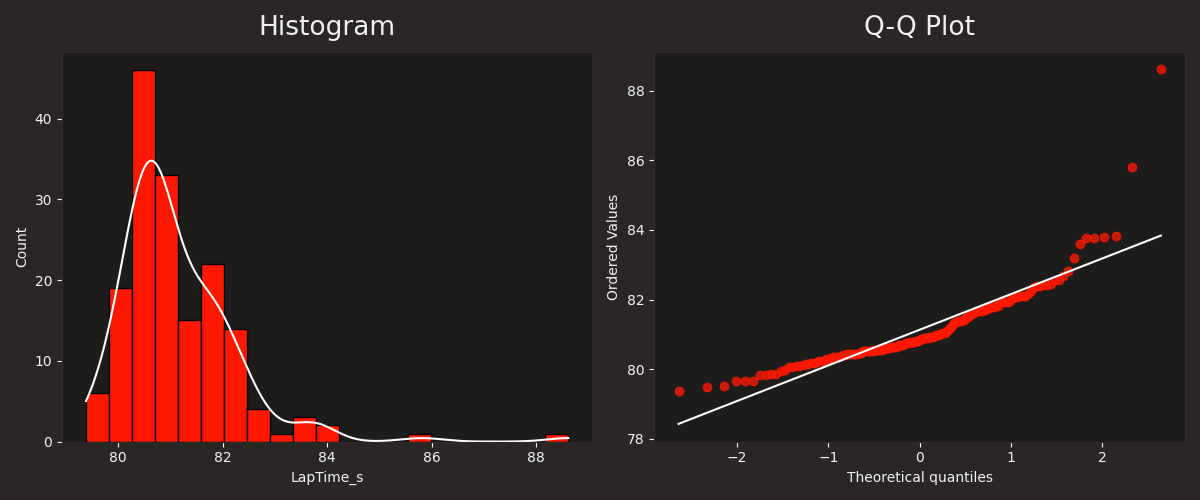

In [57]:
shapiro_wilk_test(soft.LapTime_s)
plot_normality_visual_inspection(soft.LapTime_s)

This heavy concentration on the left could be explained by the fact that soft tyres are the ones that bring the cars nearest to the physical limits of speeds for which they have been designed. These are used mainly for short stints, such as qualifying laps. We will further delve into this later.

Test stastic 0.8705
P-Value 0.0000
The data does NOT look normally distributed.


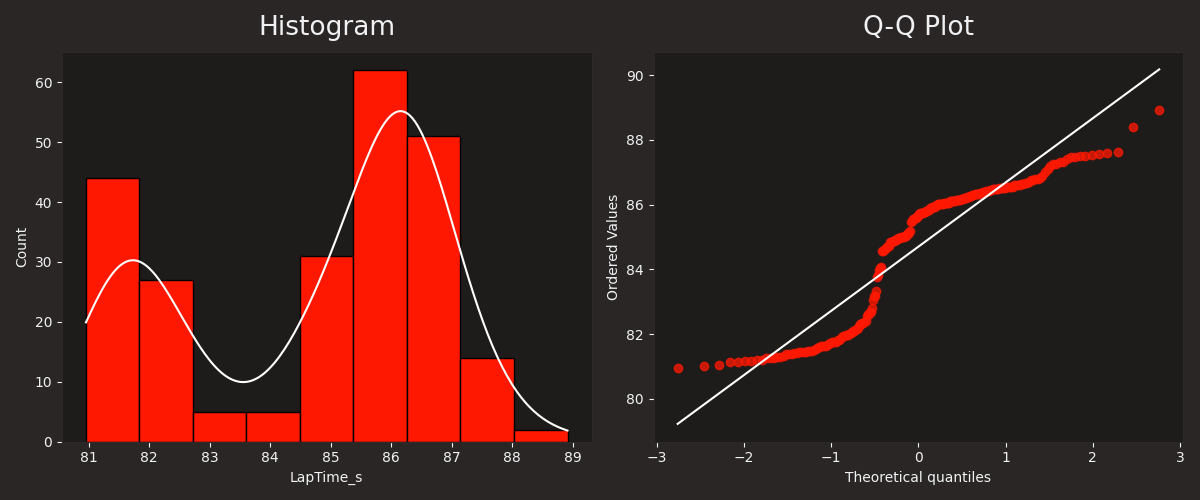

In [ ]:
shapiro_wilk_test(medium.LapTime_s)
plot_normality_visual_inspection(medium.LapTime_s)

Interestingly, there seems to be two different concentrations for medium tires. We will delve deeper into this later.

Test stastic 0.9458
P-Value 0.0000
The data does NOT look normally distributed.


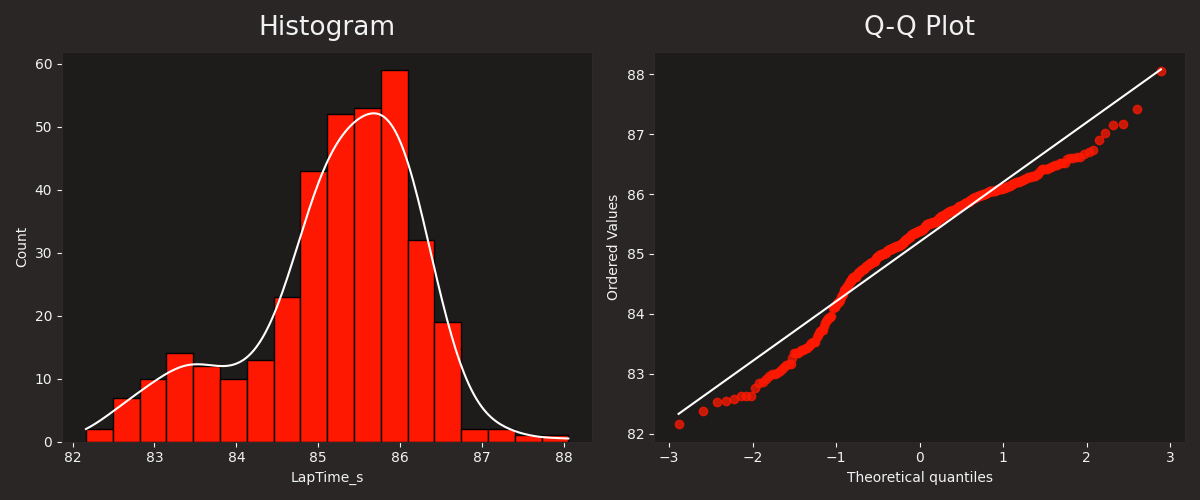

In [ ]:
shapiro_wilk_test(hard.LapTime_s)
plot_normality_visual_inspection(hard.LapTime_s)

However, for hard tyres, while the test still fails, the curve is much more bell-shaped than the others. We will also delve deeper for these.

### Analyzing general lap time by speeds registered (Intermediate 1)

As will be further explained in this notebook, the speed from the first intermediate in this circuit is decisive to establish good lap times. It is the most important part of the circuit for reducing lap times.

Test stastic 0.9466
P-Value 0.0000
The data does NOT look normally distributed.


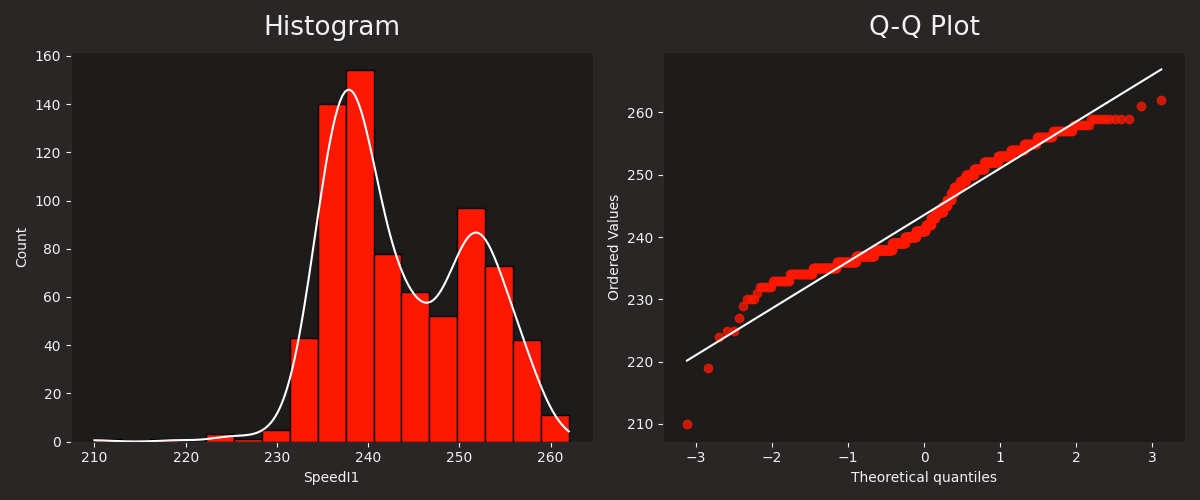

In [18]:
shapiro_wilk_test(all_laps["SpeedI1"])
plot_normality_visual_inspection(all_laps["SpeedI1"])

The curves here seem to inversely replicate the trends for the curves of the lap times, logically, as higher speeds result in faster lap times.

#### Are these actually the same distributions?

To validate whether these distributions are actually the same, but mirrored, we will do a quick standardization and flipping of the data.

All Tyre Types
D-Statistic (Max gap between distributions): 0.3696
P-Value: 0.0000
Conclusion: The distributions are statistically DIFFERENT (Reject Null).


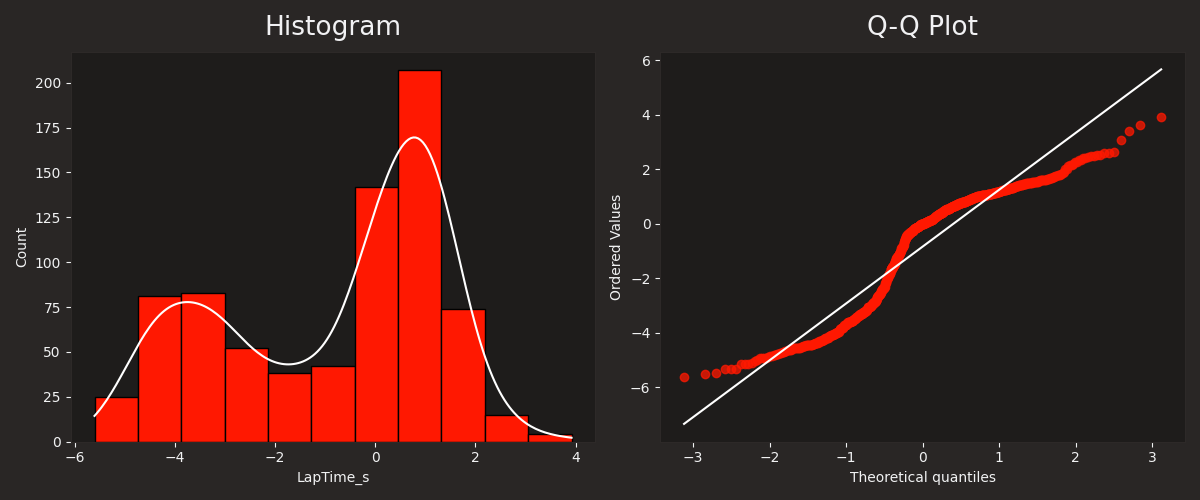

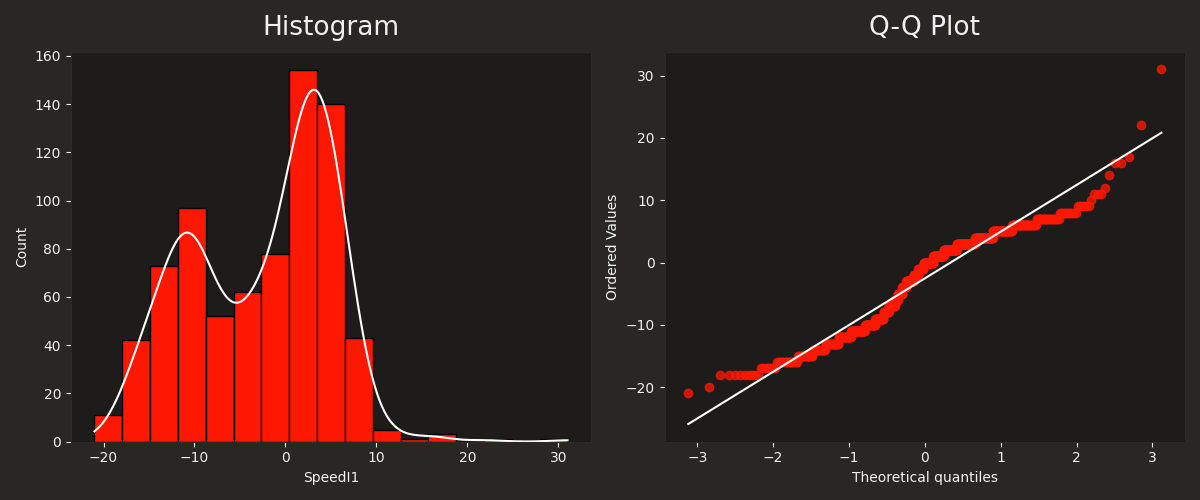

SOFT
D-Statistic (Max gap between distributions): 0.3653
P-Value: 0.0000
Conclusion: The distributions are statistically DIFFERENT (Reject Null).


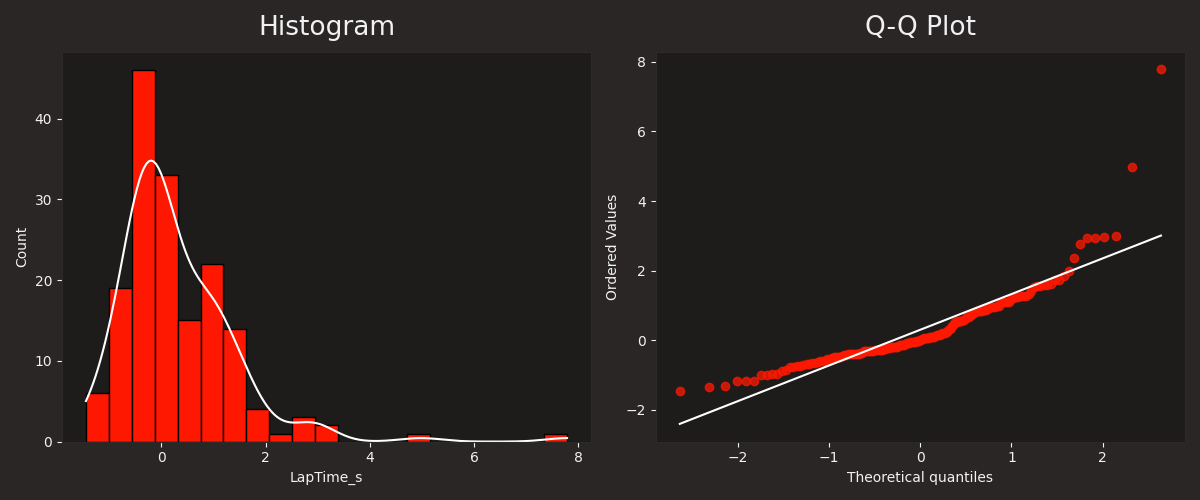

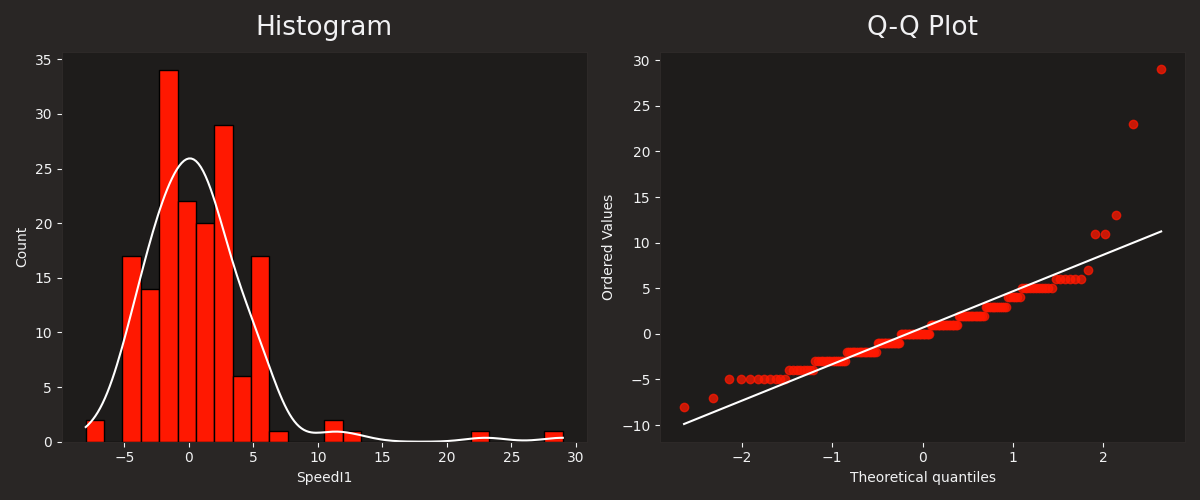

MEDIUM
D-Statistic (Max gap between distributions): 0.3610
P-Value: 0.0000
Conclusion: The distributions are statistically DIFFERENT (Reject Null).


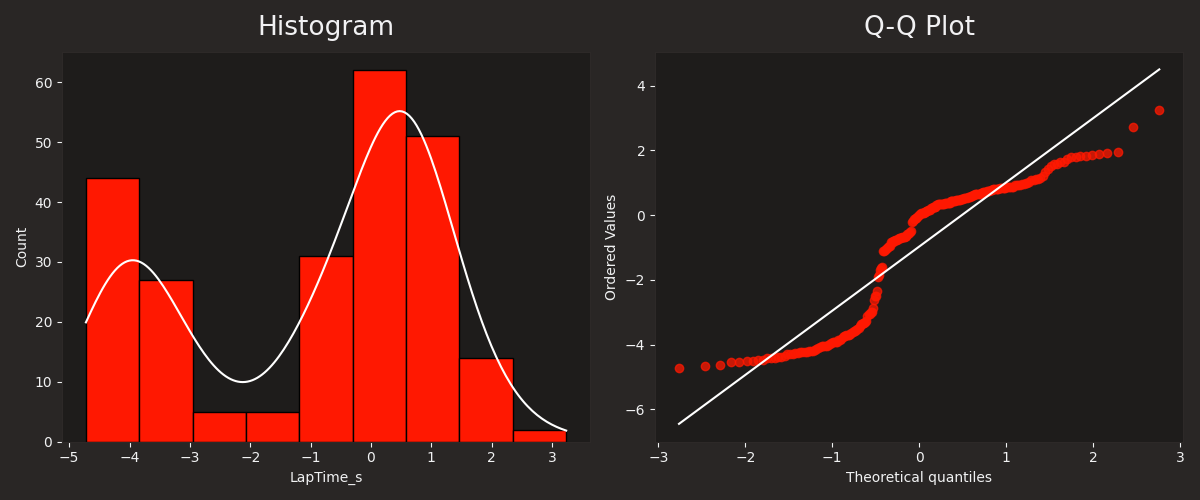

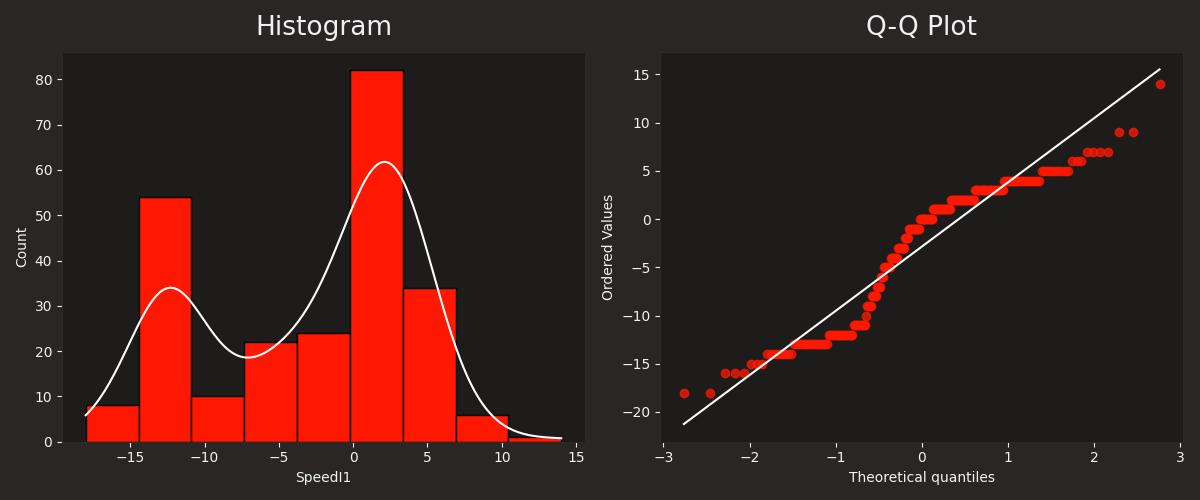

HARD
D-Statistic (Max gap between distributions): 0.3380
P-Value: 0.0000
Conclusion: The distributions are statistically DIFFERENT (Reject Null).


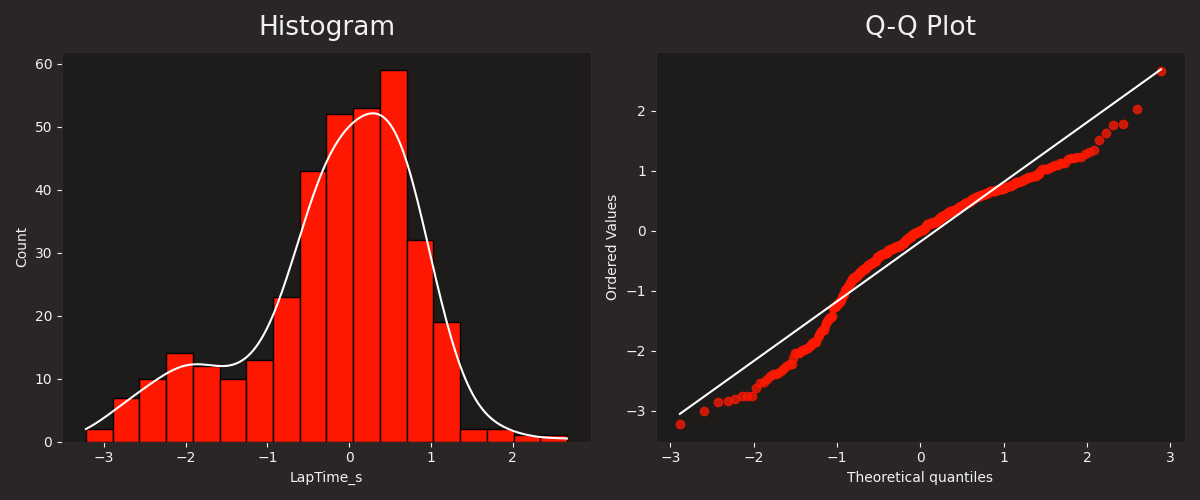

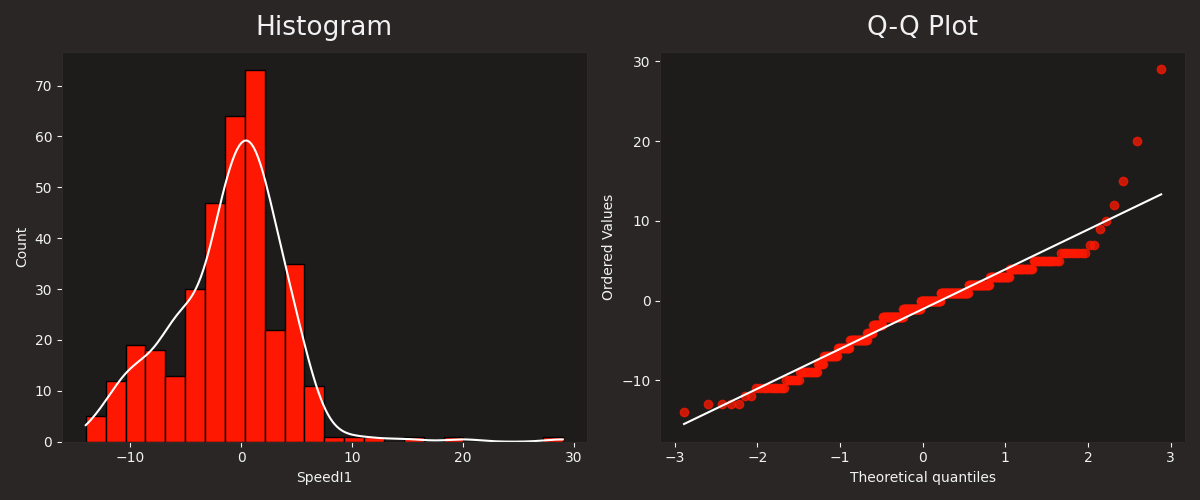

In [ ]:
TYRES_CONFIG = ["All Tyre Types", "SOFT", "MEDIUM", "HARD"]

for tyre_config, laps_data in zip(TYRES_CONFIG, [all_laps, soft, medium, hard]):
    print(tyre_config)

    speed_centered = laps_data.SpeedI1 - np.median(laps_data.SpeedI1)
    laptime_centered = laps_data.LapTime_s - np.median(laps_data.LapTime_s)

    speed_mirrored = -speed_centered

    ks_test(speed_mirrored, laptime_centered)
    plot_normality_visual_inspection(laptime_centered)
    plot_normality_visual_inspection(speed_mirrored)

Though there is statistically significant difference between the distributions, the trends still look very similar and these are highly correlated values.

## Analyzing Tyres

Tyre management is one of the most crucial areas for having success in Formula 1. As will be further explained, in this specific grand prix, it was a big part of the final positions.

As drivers complete laps, the amount of tyre wear increases, causing the tyre to lose performance and increase lap time. However, cold tyres also do not offer good grip, which is crucial for achieving good cornering speeds.

Therefore, most compounds have an optimal window of performance, balancing temperature and tyre wear.

### Analyzing Medium Tyre Compound influence on Lap Time

In [23]:
medium_median_order = medium.groupby("Team")["LapTime_s"].median().sort_values().index

team_palette = {team: plotting.get_team_color(team, session=quali) for team in medium_median_order}

c:\Users\Vitor\cesar-beat-f1-workshop\src\plots\tyres.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["TyreLifeCat"] = pd.cut(data["TyreLife"], bins=bins, labels=labels)
c:\Users\Vitor\cesar-beat-f1-workshop\src\plots\tyres.py:37: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.swarmplot(


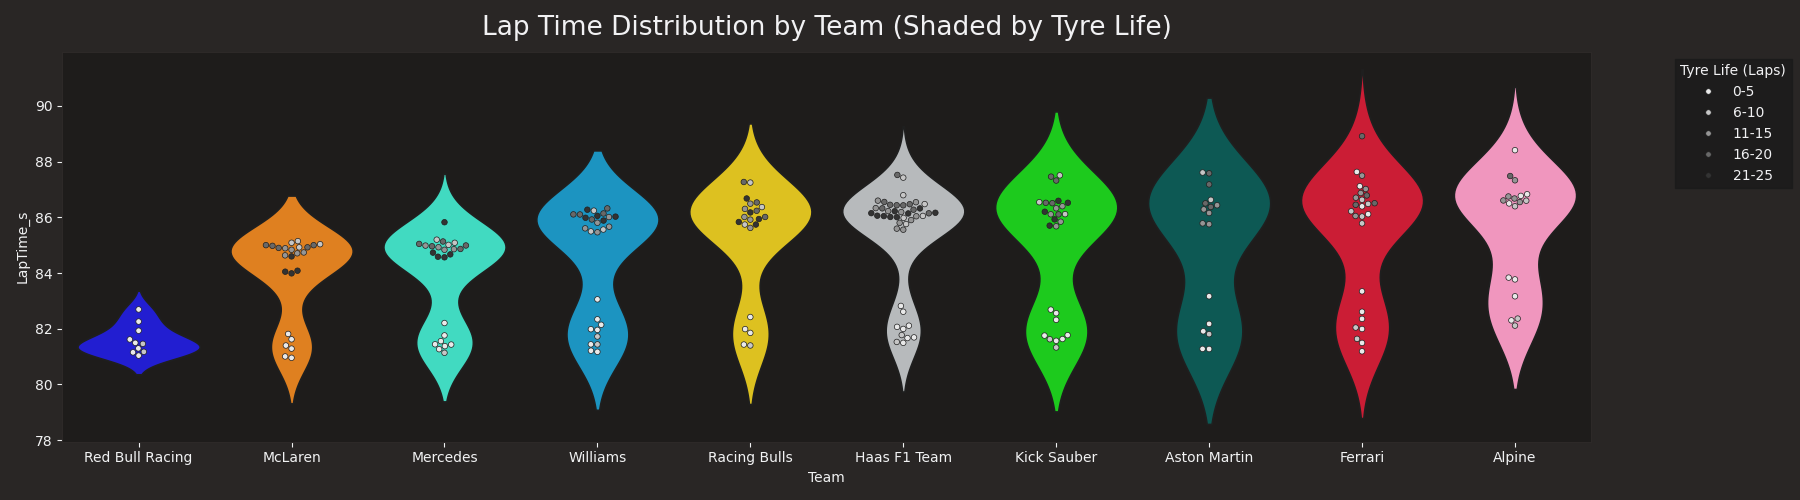

In [24]:
plot_laptime_distribution_by_team_with_tyre_life(medium, quali)

It is possible to notice that most teams follow similar distributions for Medium Tyres, where tyres older than 10 laps tend to have a drop in performance compared to their fresher counterparts. Keep in mind, however, that this is not a perfect estimate of performance since the data aggregates all sessions.

In [25]:
t1_laptimes = medium[medium["Team"] == TEAM_1]["LapTime_s"]

for position, team in enumerate(medium_median_order):
    if team == TEAM_1:
        continue
    print(f"Comparing against the # {position+1} by median order...")
    team_laptimes = medium[medium["Team"] == team]["LapTime_s"]
    mann_whitney_u_test(team_laptimes, t1_laptimes)

Comparing against the # 1 by median order...
Test stastic 39.0000
P-Value 0.0023
There is NOT a statistically significant difference between the two series.
Comparing against the # 3 by median order...
Test stastic 322.5000
P-Value 0.6599
There IS a statistically significant difference between the two series.
Comparing against the # 4 by median order...
Test stastic 479.0000
P-Value 0.0089
There is NOT a statistically significant difference between the two series.
Comparing against the # 5 by median order...
Test stastic 434.0000
P-Value 0.0002
There is NOT a statistically significant difference between the two series.
Comparing against the # 6 by median order...
Test stastic 869.0000
P-Value 0.0000
There is NOT a statistically significant difference between the two series.
Comparing against the # 7 by median order...
Test stastic 477.0000
P-Value 0.0040
There is NOT a statistically significant difference between the two series.
Comparing against the # 8 by median order...
Test stastic

This test highlights how complex trying to analyze F1 can be: even between the fastest and the slowest teams on the grid, according to the Mann-Whitney U test, it still is not possible to detect a difference between the lap time that is statistically significant regarding to measures of central tendency.

The difference between the first and second team, however, can be explained due to a larger structural difference in the distributions as the first team had not used tyres older than 10 laps in this weekend.

In [26]:
t1_laptimes = medium[medium["Team"] == TEAM_1]["LapTime_s"]

for position, team in enumerate(medium_median_order):
    if team == TEAM_1:
        continue
    print(f"Comparing against the # {position+1} by median order...")
    team_laptimes = medium[medium["Team"] == team]["LapTime_s"]
    ks_test(team_laptimes, t1_laptimes)

Comparing against the # 1 by median order...
D-Statistic (Max gap between distributions): 0.7500
P-Value: 0.0002
Conclusion: The distributions are statistically DIFFERENT (Reject Null).
Comparing against the # 3 by median order...
D-Statistic (Max gap between distributions): 0.1500
P-Value: 0.8853
Conclusion: No significant difference in distributions (Fail to Reject Null).
Comparing against the # 4 by median order...
D-Statistic (Max gap between distributions): 0.6429
P-Value: 0.0000
Conclusion: The distributions are statistically DIFFERENT (Reject Null).
Comparing against the # 5 by median order...
D-Statistic (Max gap between distributions): 0.7727
P-Value: 0.0000
Conclusion: The distributions are statistically DIFFERENT (Reject Null).
Comparing against the # 6 by median order...
D-Statistic (Max gap between distributions): 0.7727
P-Value: 0.0000
Conclusion: The distributions are statistically DIFFERENT (Reject Null).
Comparing against the # 7 by median order...
D-Statistic (Max gap

However, when testing using Kolmogorov-Smirnov, it was possible to identify differences with most of the grid, with the notable exception of team 1, as explained before, and team 4. Therefore, the main statistically significant difference between teams' laps in this weekend lies on consistency rather than mean or median pace. Keep this in mind as we analyze the race results!

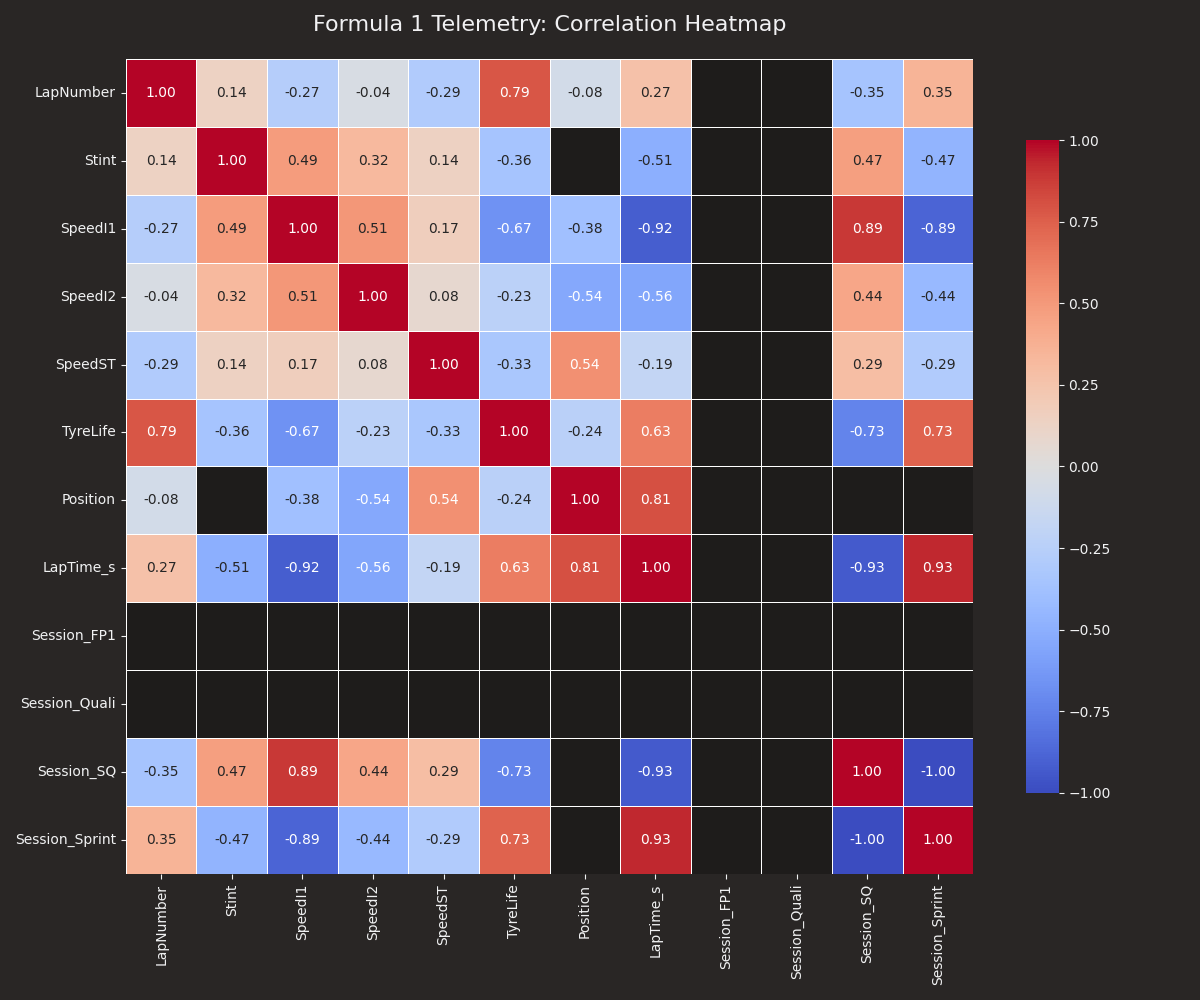


--- Correlations with LapTime_s ---
Session_Sprint    0.930530
Position          0.807094
TyreLife          0.631129
LapNumber         0.267341
SpeedST          -0.186325
Stint            -0.506221
SpeedI2          -0.556612
SpeedI1          -0.915045
Session_SQ       -0.930530
Session_FP1            NaN
Session_Quali          NaN
Name: LapTime_s, dtype: float64


In [27]:
plot_laptime_correlation_heatmap(medium)

It seems that, as expected, there is a high correlation between lap time and position (0.81). For this circuit, while using medium tyres, it seems that speed through the first intermediate is crucial to achieve lower lap times (-0.91), a big diference to the second intermediate (-0.55). The third most important feature is tyre wear (0.63) when using medium tyres. It also is highly correlated with SpeedI1 (-0.67). These data are crucial to design a race plan and where to focus on the track.

### Medium Tyre Performance Decay

Now, let's use the data to understand tyre performance decay. This can be crucial to determine pit stops and overall race strategy.

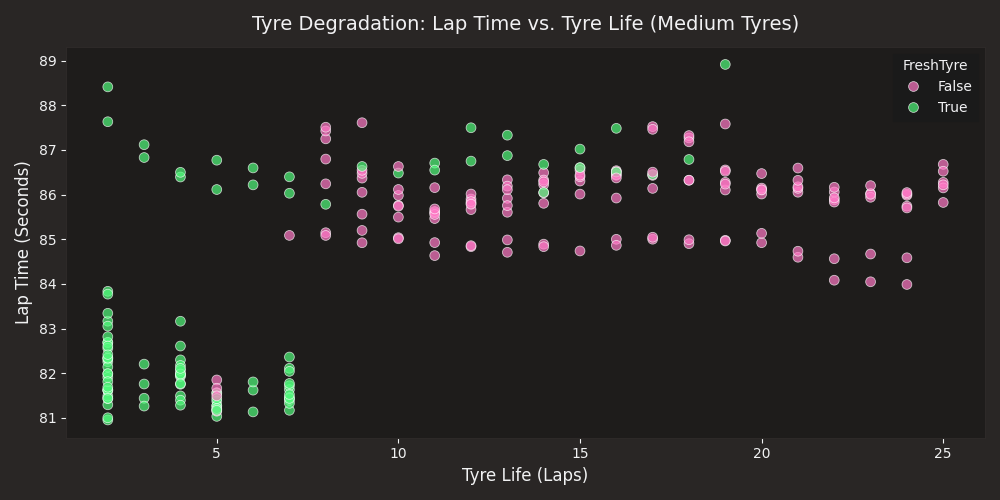

In [28]:
plot_tyre_decay_scatter_plot(medium)

There seems to be a trend in which tyres take some laps to get to their best performance, around 7 to 12 laps in. After this, performance starts to decay.

Even though there seems to be an indication that fresh tyres can be much quicker than used tyres from the above graph, be wary! We had previously aggregated all sessions.

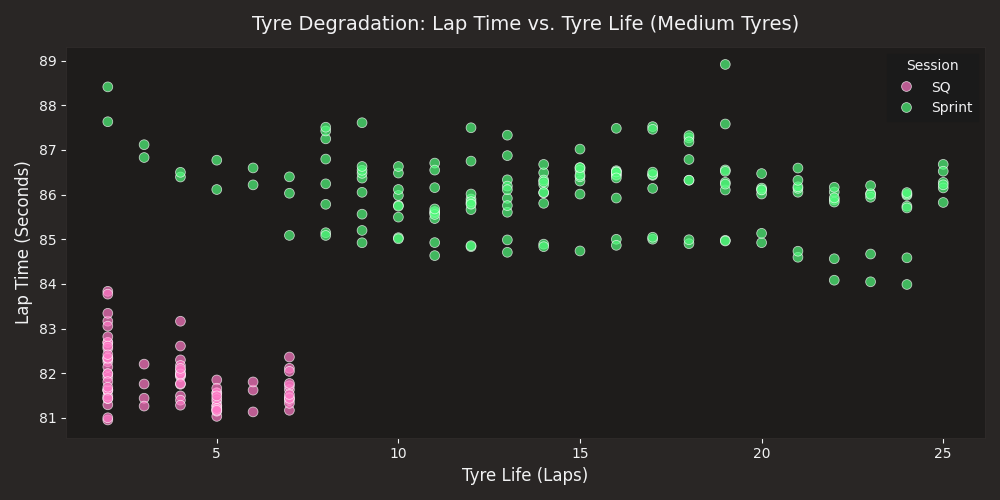

In [29]:
plot_tyre_decay_scatter_plot(medium, hue="Session")

In [30]:
mann_whitney_u_test(medium[medium.Session_SQ == 1]["LapTime_s"], medium[medium.Session_Sprint == 1]["LapTime_s"])
ks_test(medium[medium.Session_SQ == 1]["LapTime_s"], medium[medium.Session_Sprint == 1]["LapTime_s"])

Test stastic 0.0000
P-Value 0.0000
There is NOT a statistically significant difference between the two series.
D-Statistic (Max gap between distributions): 1.0000
P-Value: 0.0000
Conclusion: The distributions are statistically DIFFERENT (Reject Null).


(np.float64(1.0), np.float64(4.630625161998186e-65))

While, once again, measures of central tendency are very similar between the two types of session, the distributions are statistically different for lap times.

Having a sprint session is very useful! Let's see just by how much lap time changes according to tyre wear, using the sprint session.

In [31]:
def format_delta(val) -> str | None:
    return None if pd.isna(val) else val

c:\Users\Vitor\cesar-beat-f1-workshop\src\plots\tyres.py:90: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(18, 6))


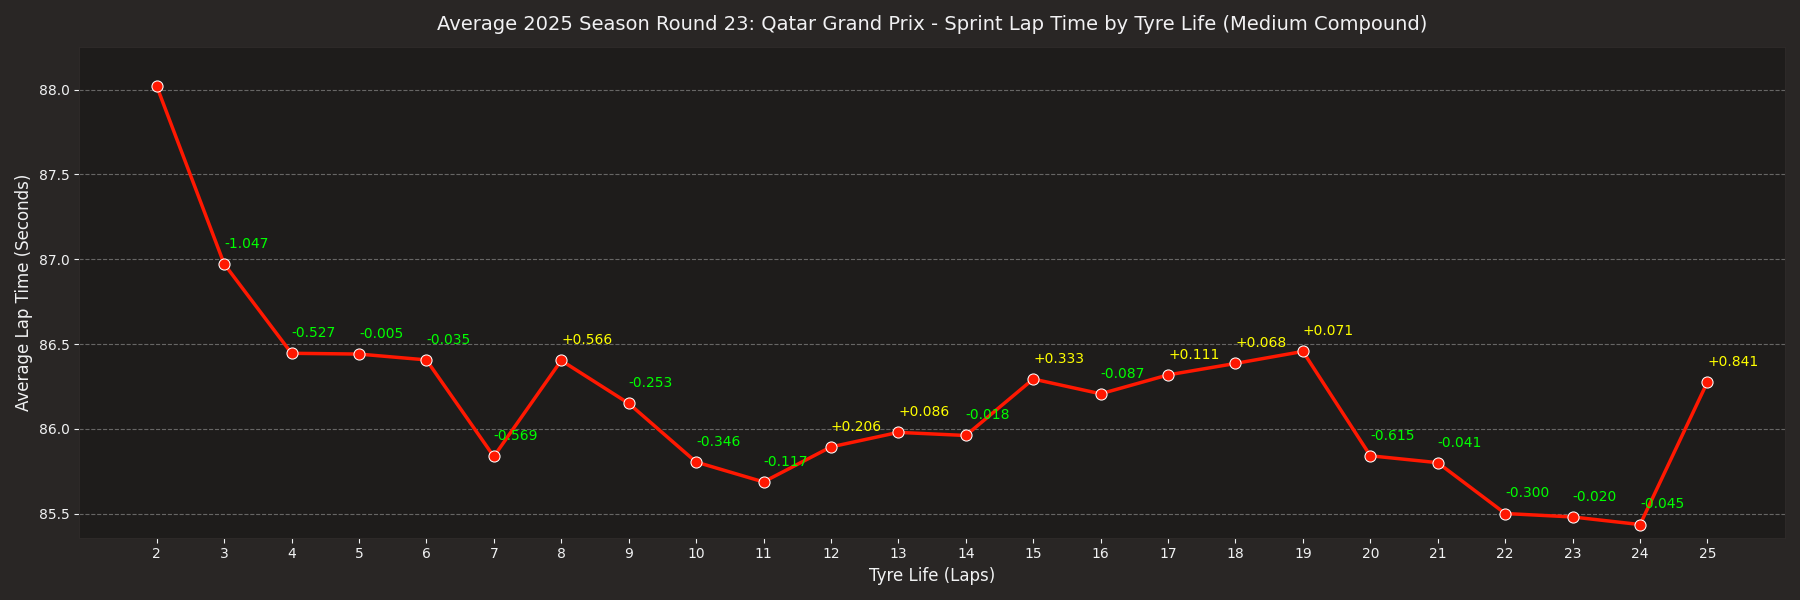

In [32]:
mean_laps_by_life = get_tyre_life_stats(medium, format_delta, is_sprint=True)
plot_average_lap_time_by_tyre_wear(mean_laps_by_life, "Medium", sprint)

Therefore, the data seems to indicate that the optimal performance window for medium tyres lies between 8 to 15 laps.

Let's now take a look at the general correlations between positions, lap time and other features.

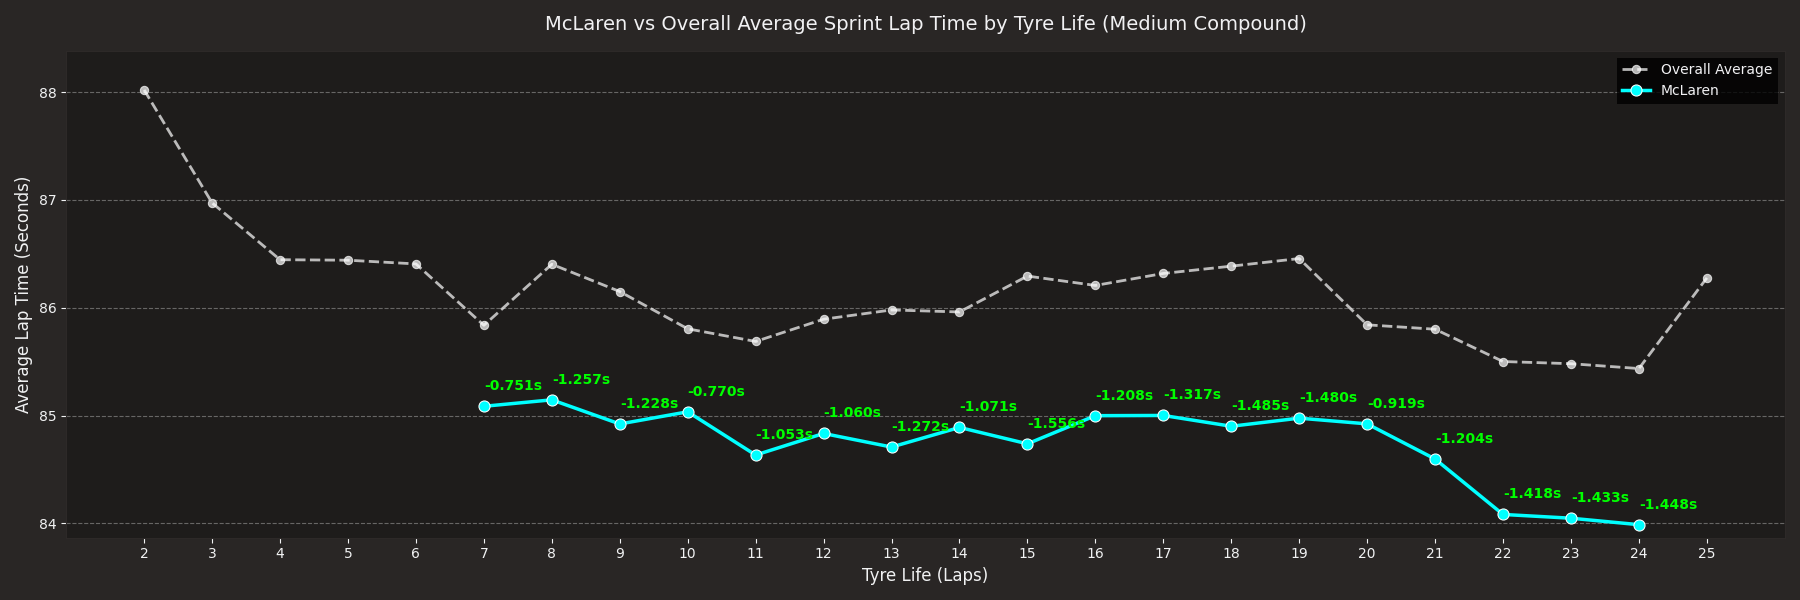

In [33]:
team_mean_laps_by_life = get_tyre_life_stats(medium.pick_teams(TEAM_1), format_delta, is_sprint=True)
plot_team_vs_overall_tyre_wear(mean_laps_by_life, team_mean_laps_by_life, TEAM_1, "MEDIUM", "Sprint")

In [34]:
print(f"Overall average lap time: {mean_laps_by_life["LapTime_s"].mean()} +/- {mean_laps_by_life["LapTime_s"].std()}")

Overall average lap time: 86.16672321428571 +/- 0.5454475225424834


In [35]:
print(f"Our team's average lap time: {team_mean_laps_by_life["LapTime_s"].mean()} +/- {team_mean_laps_by_life["LapTime_s"].std()}")

Our team's average lap time: 84.7505 +/- 0.359173110810667


Not only the average lap time is lower, but the standard deviation is also lower, establishing consistency. Also, from the graph, it is possible to see less dramatic spikes in lap time. But the tests still bring the same hypotheses:

In [36]:
mann_whitney_u_test(mean_laps_by_life["LapTime_s"], team_mean_laps_by_life["LapTime_s"])
ks_test(mean_laps_by_life["LapTime_s"], team_mean_laps_by_life["LapTime_s"])

Test stastic 432.0000
P-Value 0.0000
There is NOT a statistically significant difference between the two series.
D-Statistic (Max gap between distributions): 1.0000
P-Value: 0.0000
Conclusion: The distributions are statistically DIFFERENT (Reject Null).


(np.float64(1.0), np.float64(5.6545554966993126e-12))

## Analyzing Hard Tyre Compound influence on LapTime

In [37]:
median_order = hard.groupby("Team")["LapTime_s"].median().sort_values().index

team_palette = {team: plotting.get_team_color(team, session=quali) for team in median_order}

c:\Users\Vitor\cesar-beat-f1-workshop\src\plots\tyres.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["TyreLifeCat"] = pd.cut(data["TyreLife"], bins=bins, labels=labels)
c:\Users\Vitor\cesar-beat-f1-workshop\src\plots\tyres.py:37: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.swarmplot(


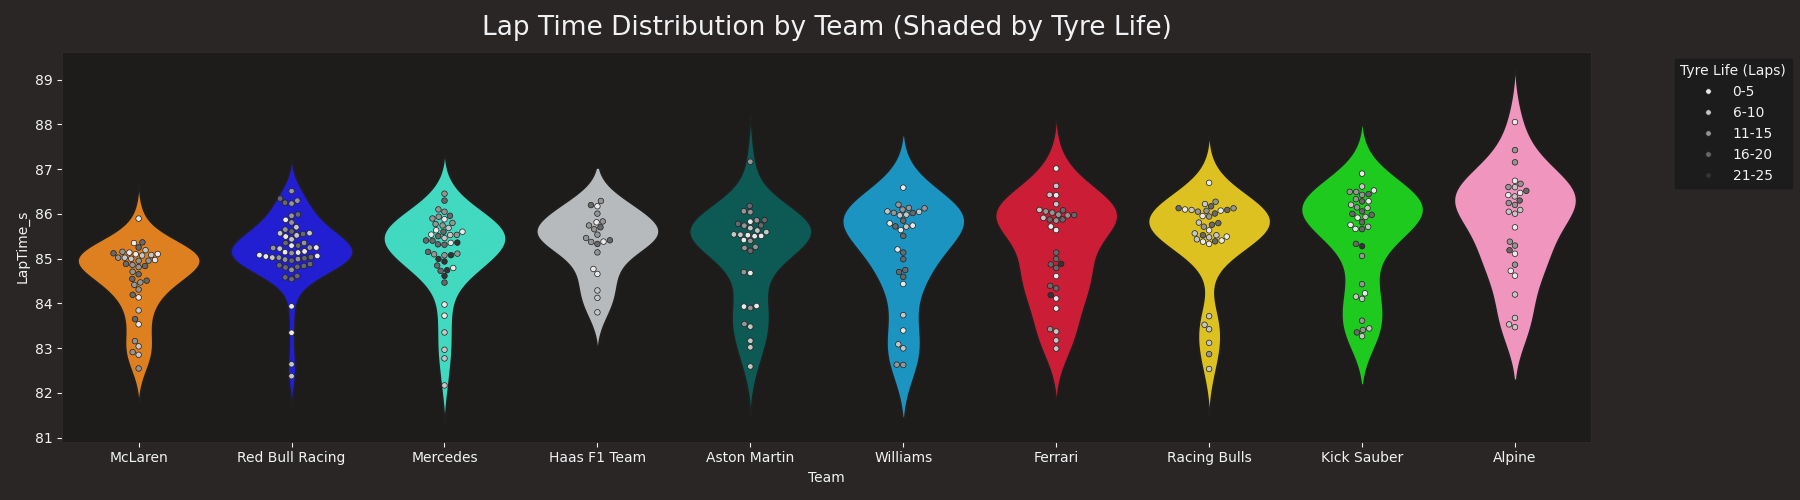

In [38]:
plot_laptime_distribution_by_team_with_tyre_life(hard, quali)

In [39]:
t1_laptimes = hard[hard["Team"] == TEAM_1]["LapTime_s"]

for position, team in enumerate(median_order):
    if team == TEAM_1:
        continue
    print(f"Comparing against the # {position+1} by median order...")
    team_laptimes = hard[hard["Team"] == team]["LapTime_s"]
    mann_whitney_u_test(team_laptimes, t1_laptimes)

Comparing against the # 2 by median order...
Test stastic 1534.5000
P-Value 0.0001
There is NOT a statistically significant difference between the two series.
Comparing against the # 3 by median order...
Test stastic 1304.0000
P-Value 0.0001
There is NOT a statistically significant difference between the two series.
Comparing against the # 4 by median order...
Test stastic 663.0000
P-Value 0.0001
There is NOT a statistically significant difference between the two series.
Comparing against the # 5 by median order...
Test stastic 945.0000
P-Value 0.0007
There is NOT a statistically significant difference between the two series.
Comparing against the # 6 by median order...
Test stastic 868.0000
P-Value 0.0019
There is NOT a statistically significant difference between the two series.
Comparing against the # 7 by median order...
Test stastic 891.5000
P-Value 0.0052
There is NOT a statistically significant difference between the two series.
Comparing against the # 8 by median order...
Test 

In [40]:
t1_laptimes = hard[hard["Team"] == TEAM_1]["LapTime_s"]

for position, team in enumerate(median_order):
    if team == TEAM_1:
        continue
    print(f"Comparing against the # {position+1} by median order...")
    team_laptimes = hard[hard["Team"] == team]["LapTime_s"]
    ks_test(team_laptimes, t1_laptimes)

Comparing against the # 2 by median order...
D-Statistic (Max gap between distributions): 0.3933
P-Value: 0.0012
Conclusion: The distributions are statistically DIFFERENT (Reject Null).
Comparing against the # 3 by median order...
D-Statistic (Max gap between distributions): 0.5009
P-Value: 0.0000
Conclusion: The distributions are statistically DIFFERENT (Reject Null).
Comparing against the # 4 by median order...
D-Statistic (Max gap between distributions): 0.6410
P-Value: 0.0000
Conclusion: The distributions are statistically DIFFERENT (Reject Null).
Comparing against the # 5 by median order...
D-Statistic (Max gap between distributions): 0.5804
P-Value: 0.0000
Conclusion: The distributions are statistically DIFFERENT (Reject Null).
Comparing against the # 6 by median order...
D-Statistic (Max gap between distributions): 0.5550
P-Value: 0.0000
Conclusion: The distributions are statistically DIFFERENT (Reject Null).
Comparing against the # 7 by median order...
D-Statistic (Max gap betw

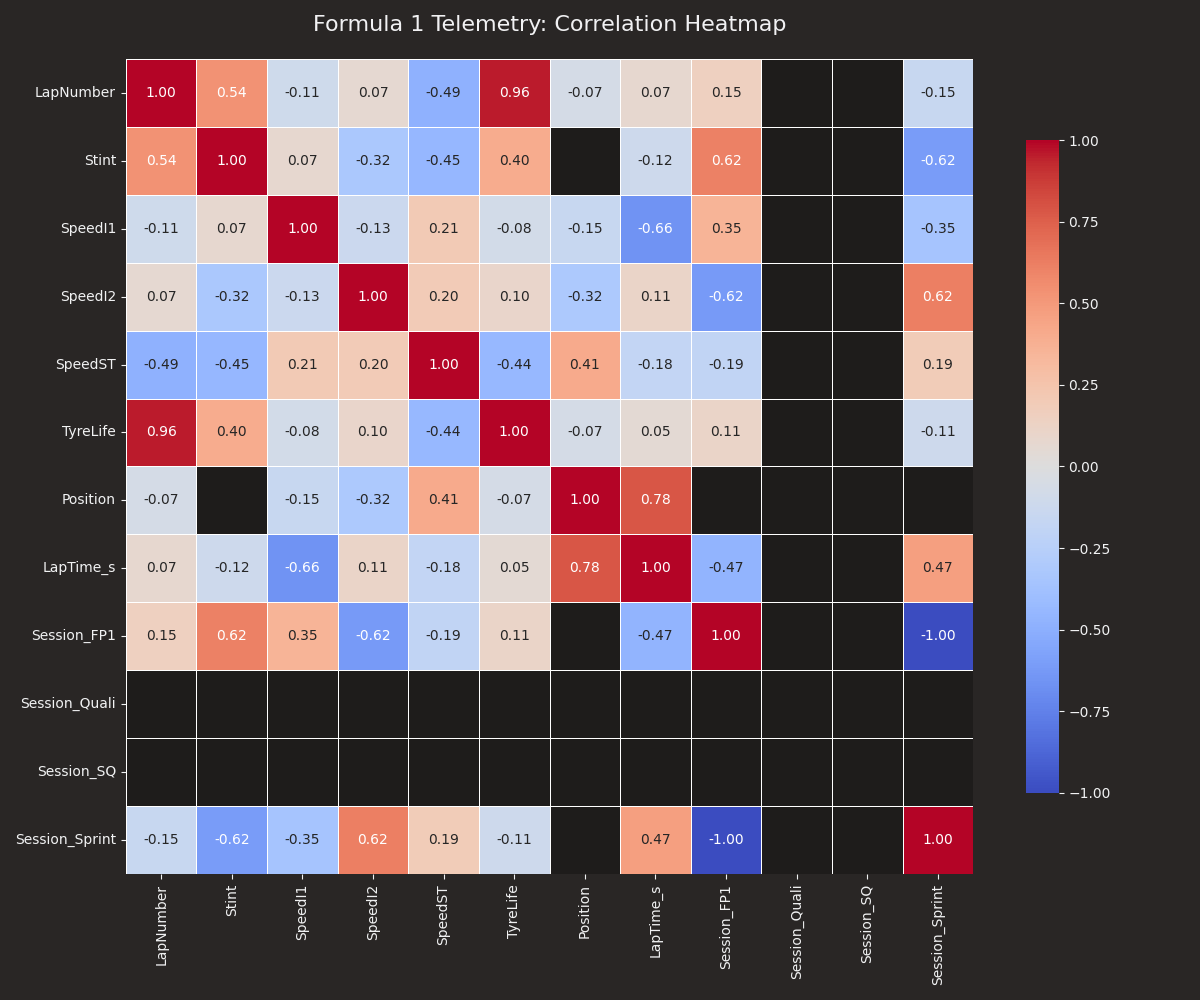


--- Correlations with LapTime_s ---
Position          0.781599
Session_Sprint    0.469567
SpeedI2           0.110199
LapNumber         0.072737
TyreLife          0.051267
Stint            -0.116887
SpeedST          -0.179799
Session_FP1      -0.469567
SpeedI1          -0.660025
Session_Quali          NaN
Session_SQ             NaN
Name: LapTime_s, dtype: float64


In [41]:
plot_laptime_correlation_heatmap(hard)

### Hard Tyre Compound performance decay

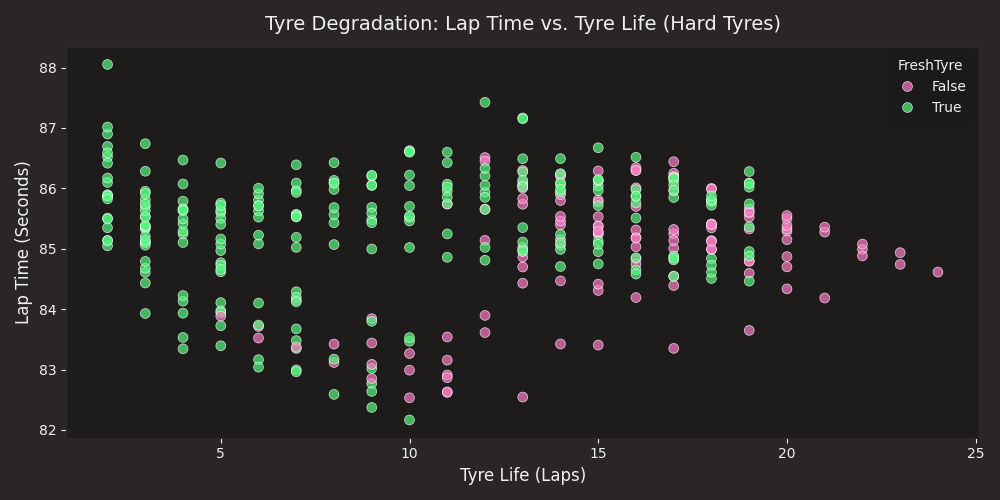

In [42]:
plot_tyre_decay_scatter_plot(hard)

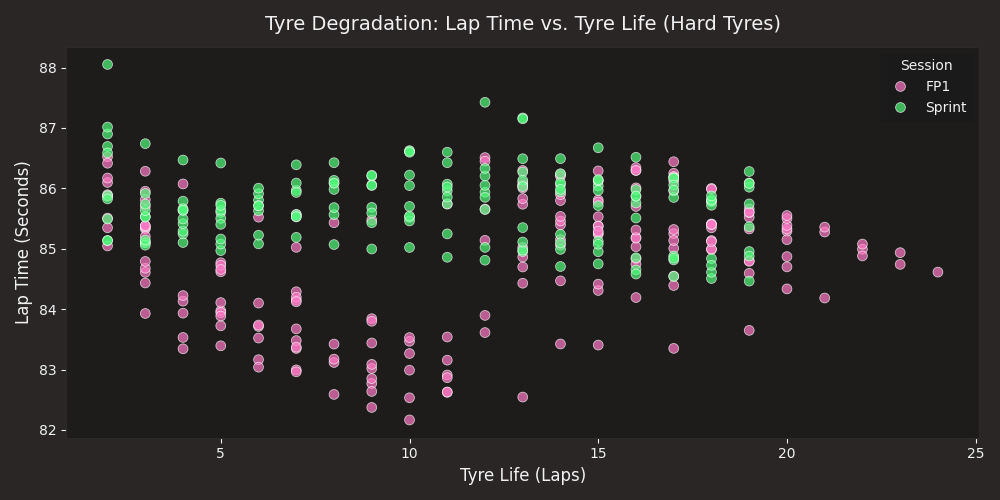

In [43]:
plot_tyre_decay_scatter_plot(hard, hue="Session")

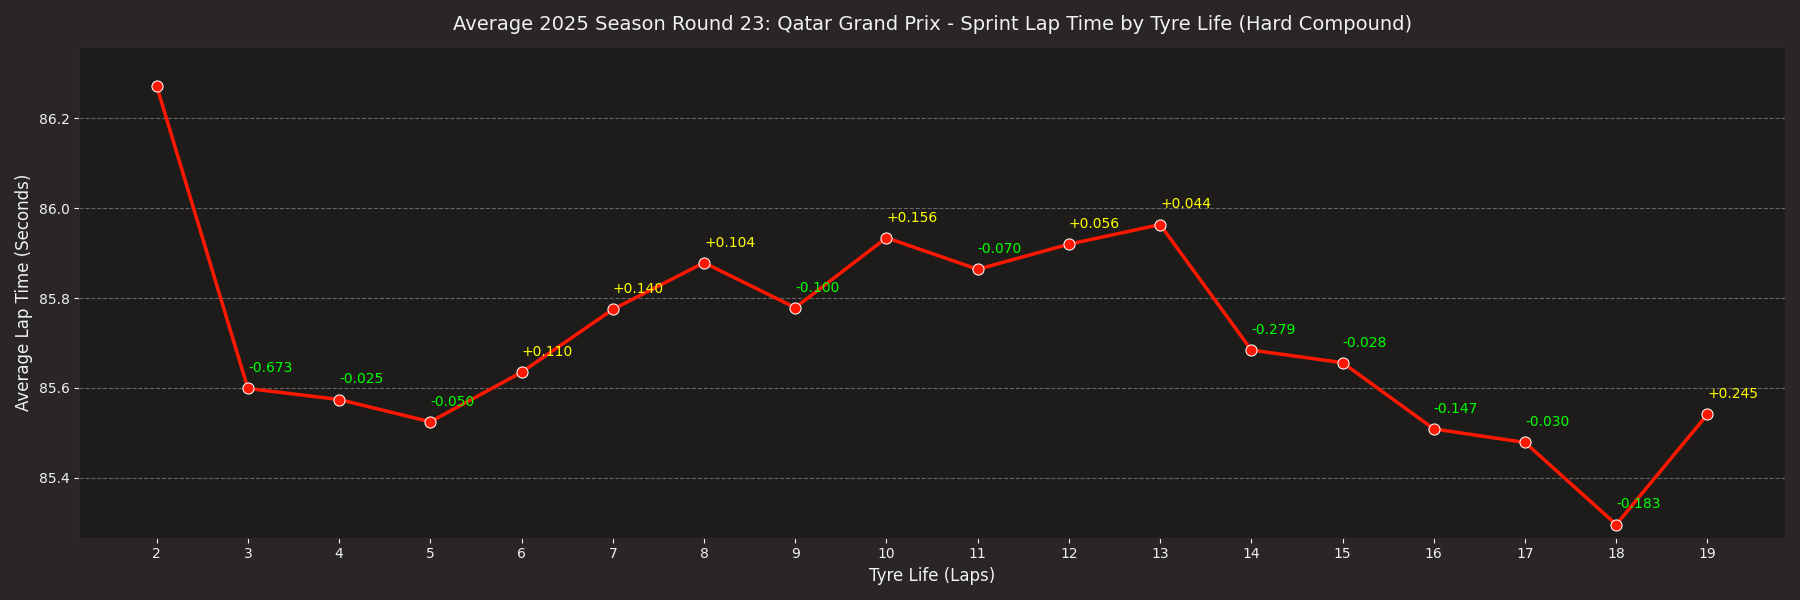

In [44]:
mean_laps_by_life = get_tyre_life_stats(hard, format_delta, is_sprint=True)
plot_average_lap_time_by_tyre_wear(mean_laps_by_life, "Hard", sprint)

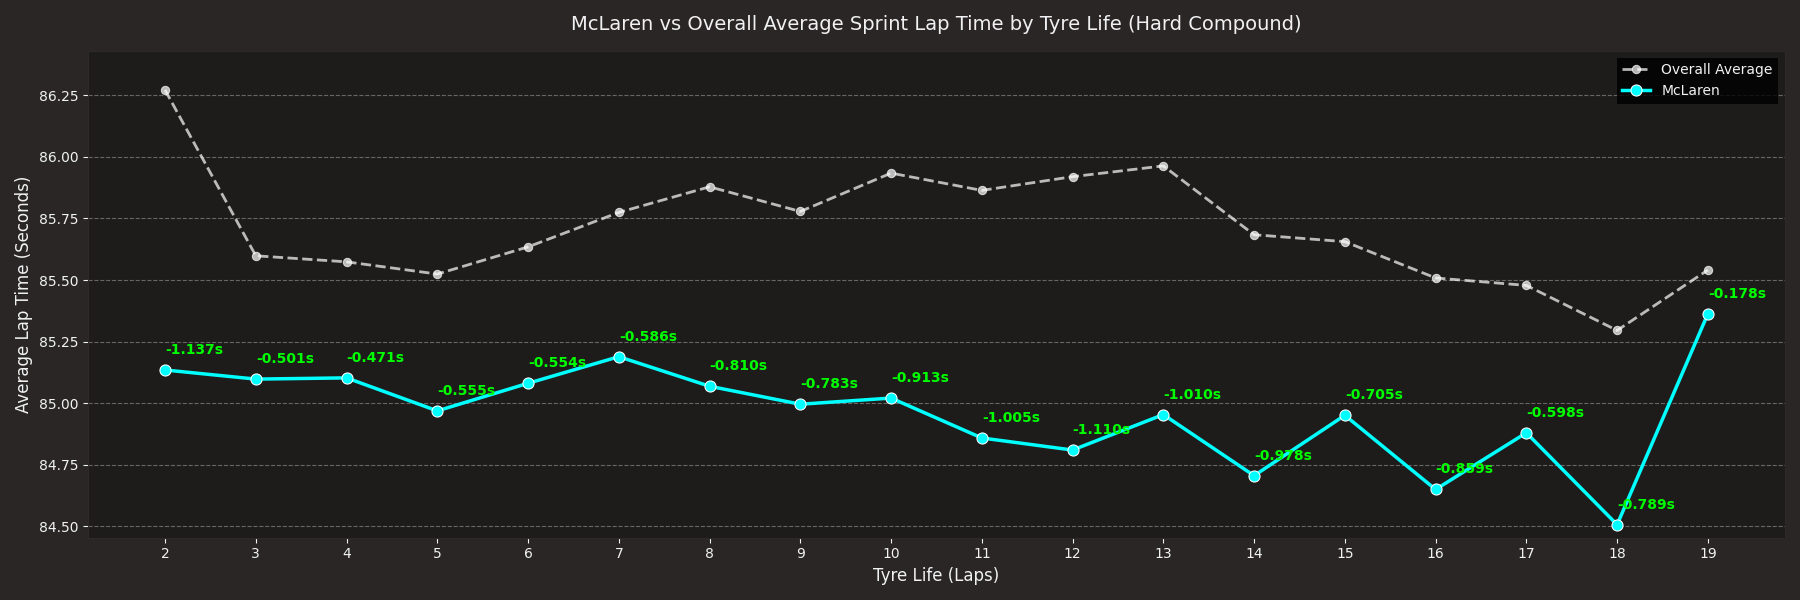

In [45]:
team_mean_laps_by_life = get_tyre_life_stats(hard.pick_teams(TEAM_1), format_delta, is_sprint=True)
plot_team_vs_overall_tyre_wear(mean_laps_by_life, team_mean_laps_by_life, TEAM_1, "HARD", "Sprint")

## Analyzing Soft Tyre Compound influence on lap time

In [46]:
soft_median_order = soft.groupby("Team")["LapTime_s"].median().sort_values().index

team_palette = {team: plotting.get_team_color(team, session=quali) for team in soft_median_order}

c:\Users\Vitor\cesar-beat-f1-workshop\src\plots\tyres.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["TyreLifeCat"] = pd.cut(data["TyreLife"], bins=bins, labels=labels)
c:\Users\Vitor\cesar-beat-f1-workshop\src\plots\tyres.py:37: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.swarmplot(


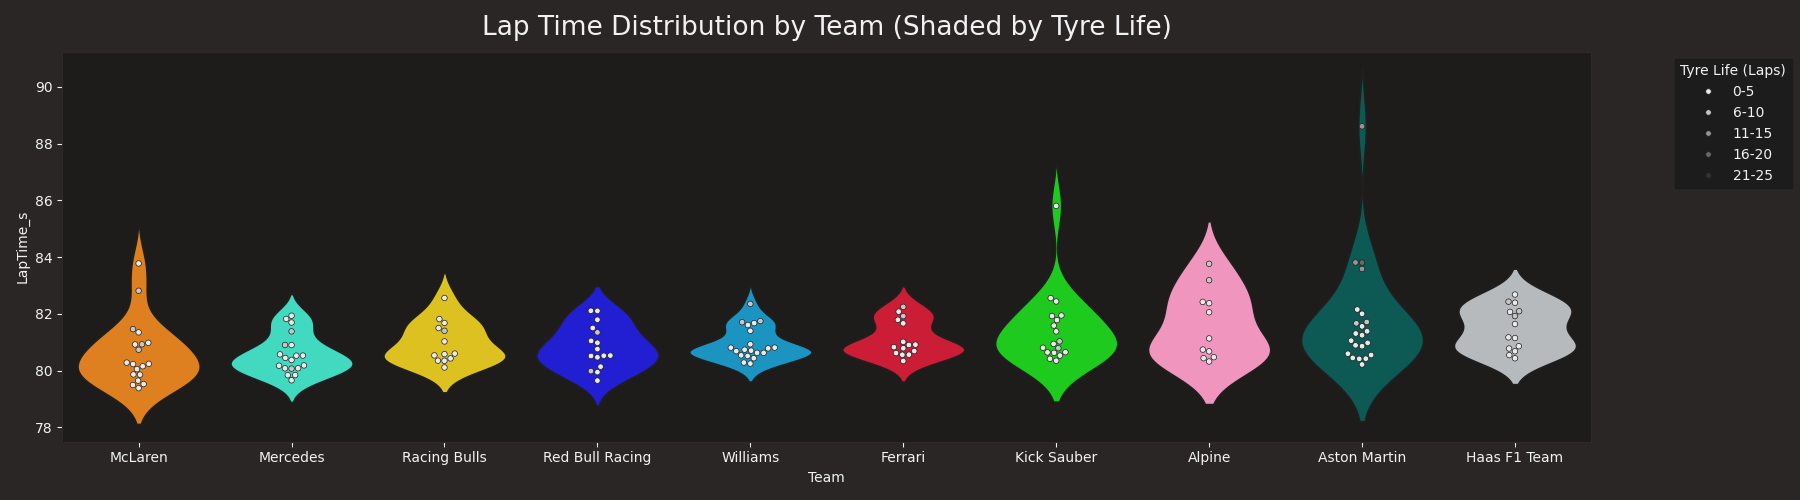

In [47]:
plot_laptime_distribution_by_team_with_tyre_life(soft, quali)

Due to the low number of data points using soft tyres, we will skip Mann-Whitney U tests as they may become imprecise.

In [48]:
t1_laptimes = soft[soft["Team"] == TEAM_1]["LapTime_s"]

for position, team in enumerate(soft_median_order):
    if team == TEAM_1:
        continue
    print(f"Comparing against the # {position+1} by median order...")
    team_laptimes = soft[soft["Team"] == team]["LapTime_s"]
    ks_test(team_laptimes, t1_laptimes)

Comparing against the # 2 by median order...
D-Statistic (Max gap between distributions): 0.2105
P-Value: 0.8081
Conclusion: No significant difference in distributions (Fail to Reject Null).
Comparing against the # 3 by median order...
D-Statistic (Max gap between distributions): 0.5020
P-Value: 0.0283
Conclusion: The distributions are statistically DIFFERENT (Reject Null).
Comparing against the # 4 by median order...
D-Statistic (Max gap between distributions): 0.3289
P-Value: 0.2409
Conclusion: No significant difference in distributions (Fail to Reject Null).
Comparing against the # 5 by median order...
D-Statistic (Max gap between distributions): 0.5289
P-Value: 0.0060
Conclusion: The distributions are statistically DIFFERENT (Reject Null).
Comparing against the # 6 by median order...
D-Statistic (Max gap between distributions): 0.5789
P-Value: 0.0034
Conclusion: The distributions are statistically DIFFERENT (Reject Null).
Comparing against the # 7 by median order...
D-Statistic (Ma

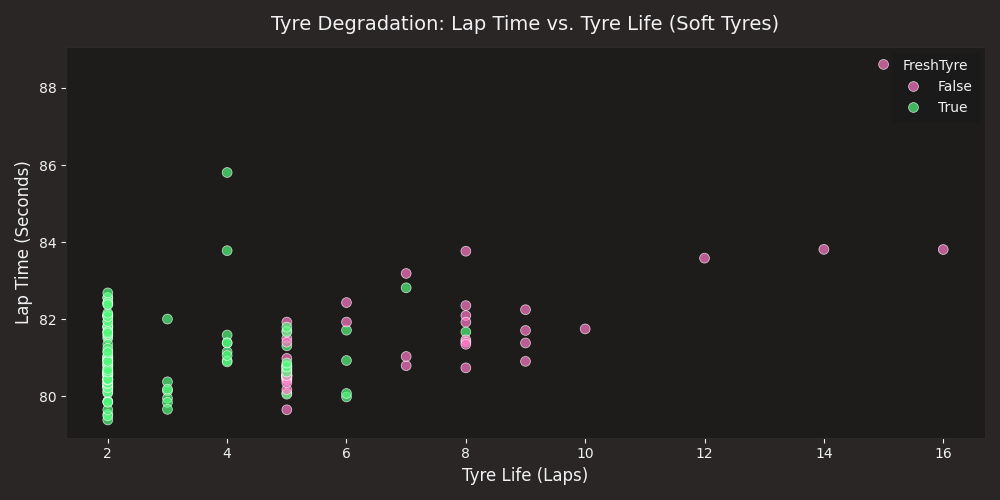

In [49]:
plot_tyre_decay_scatter_plot(soft)

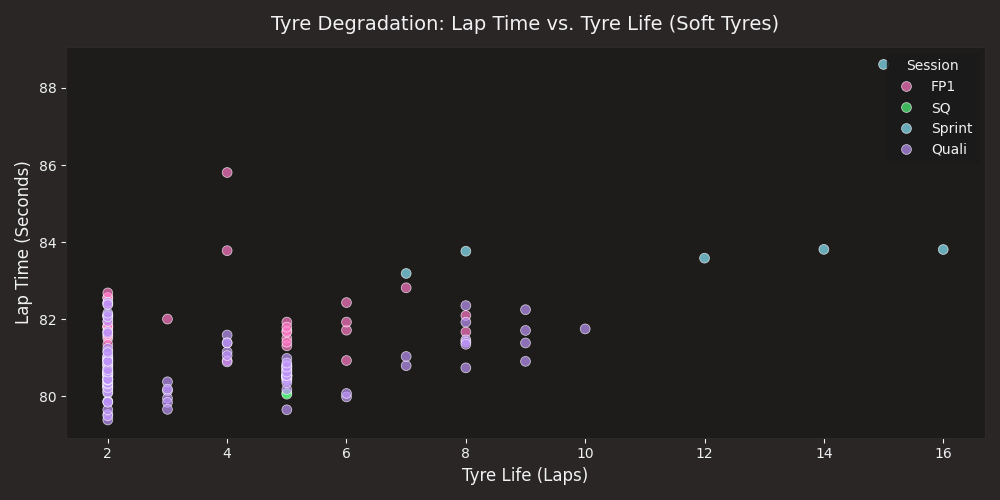

In [50]:
plot_tyre_decay_scatter_plot(soft, hue="Session")

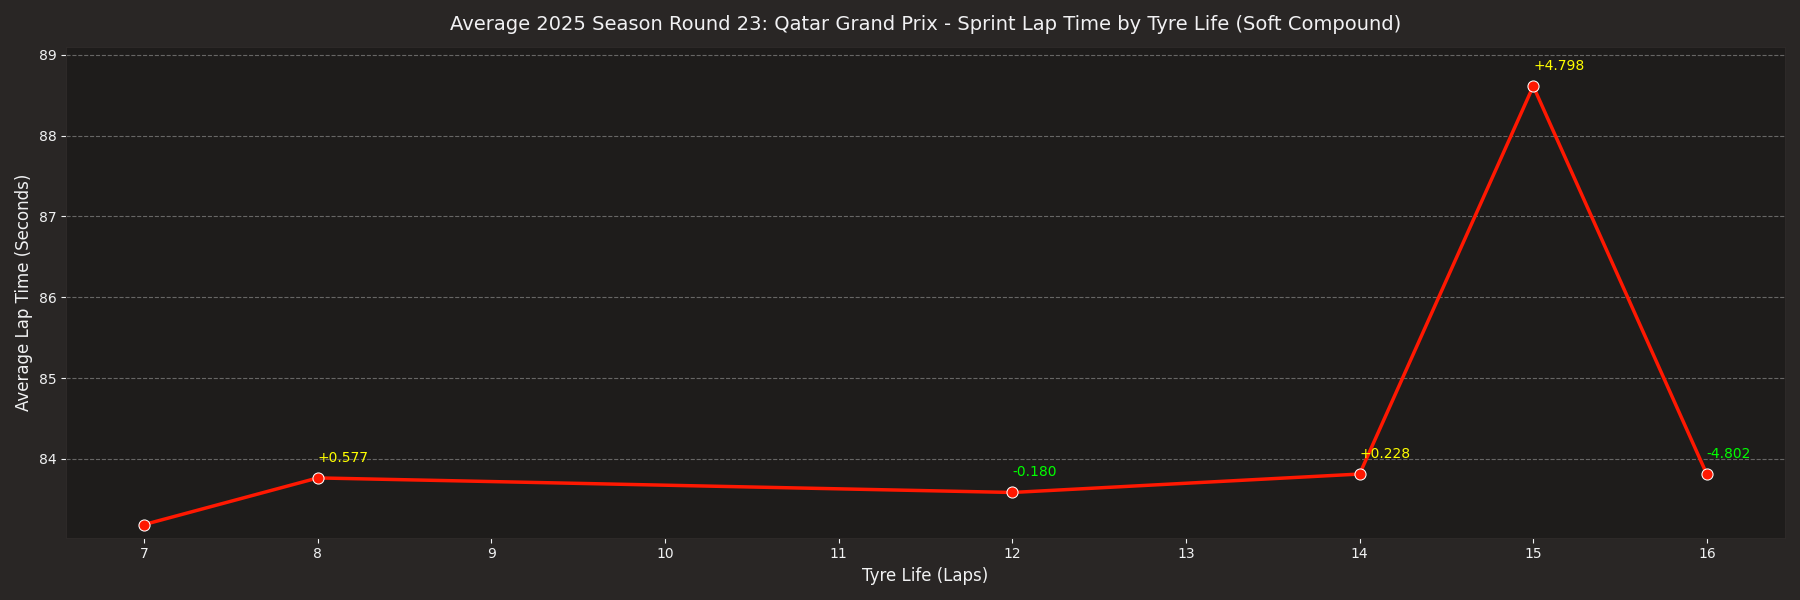

In [51]:
mean_laps_by_life = get_tyre_life_stats(soft, format_delta, is_sprint=True)
plot_average_lap_time_by_tyre_wear(mean_laps_by_life, "Soft", sprint)

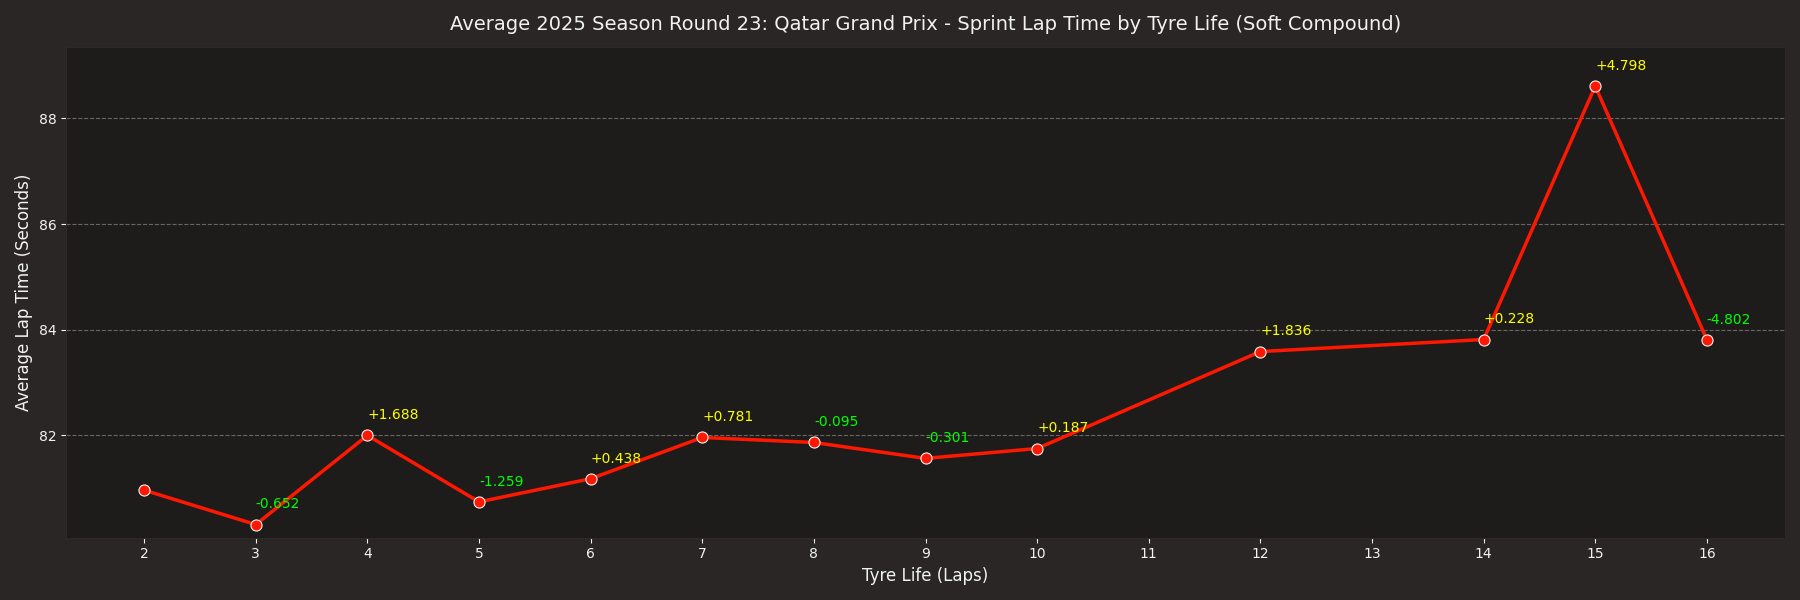

In [52]:
mean_laps_by_life = get_tyre_life_stats(soft, format_delta)
plot_average_lap_time_by_tyre_wear(mean_laps_by_life, "Soft", sprint)

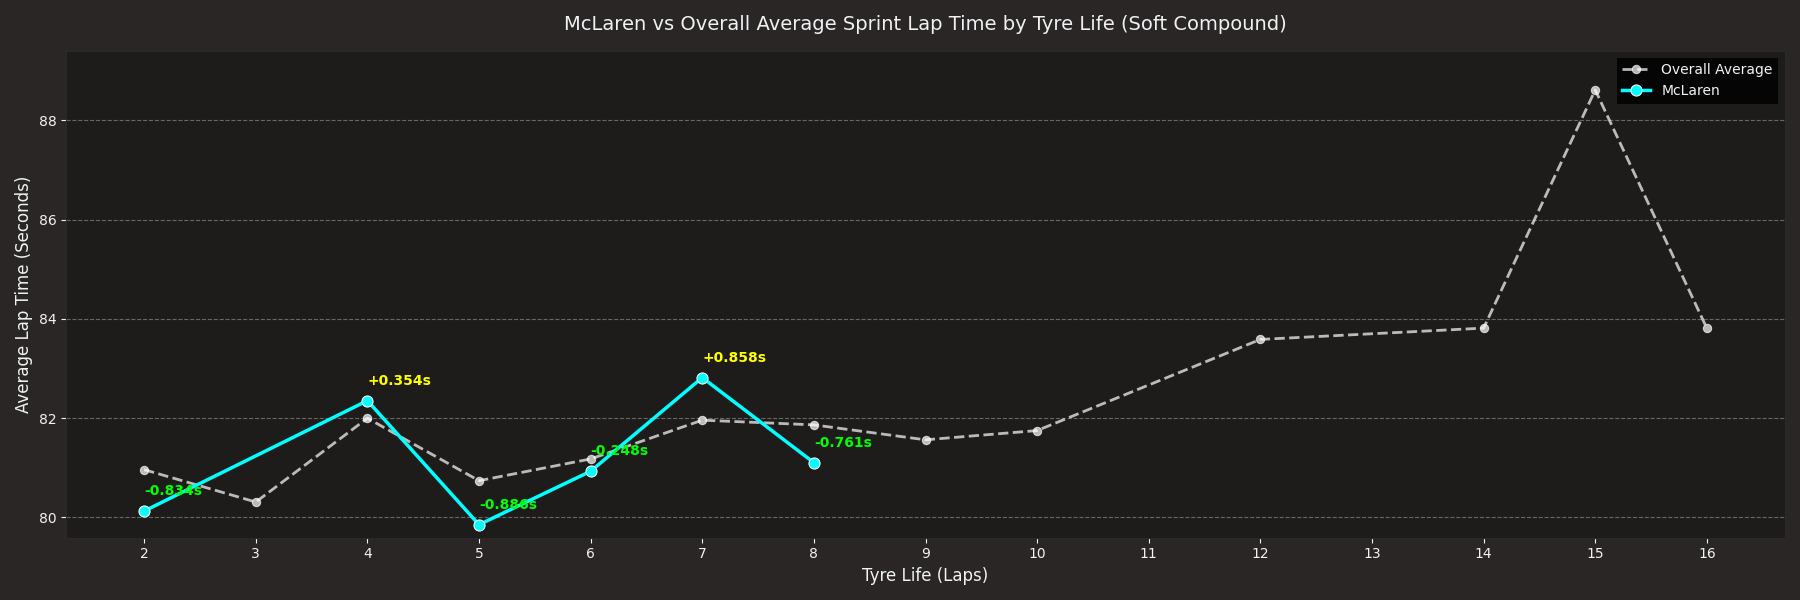

In [53]:
team_mean_laps_by_life = get_tyre_life_stats(soft.pick_teams(TEAM_1), format_delta)
plot_team_vs_overall_tyre_wear(mean_laps_by_life, team_mean_laps_by_life, TEAM_1, "SOFT", "Sprint")

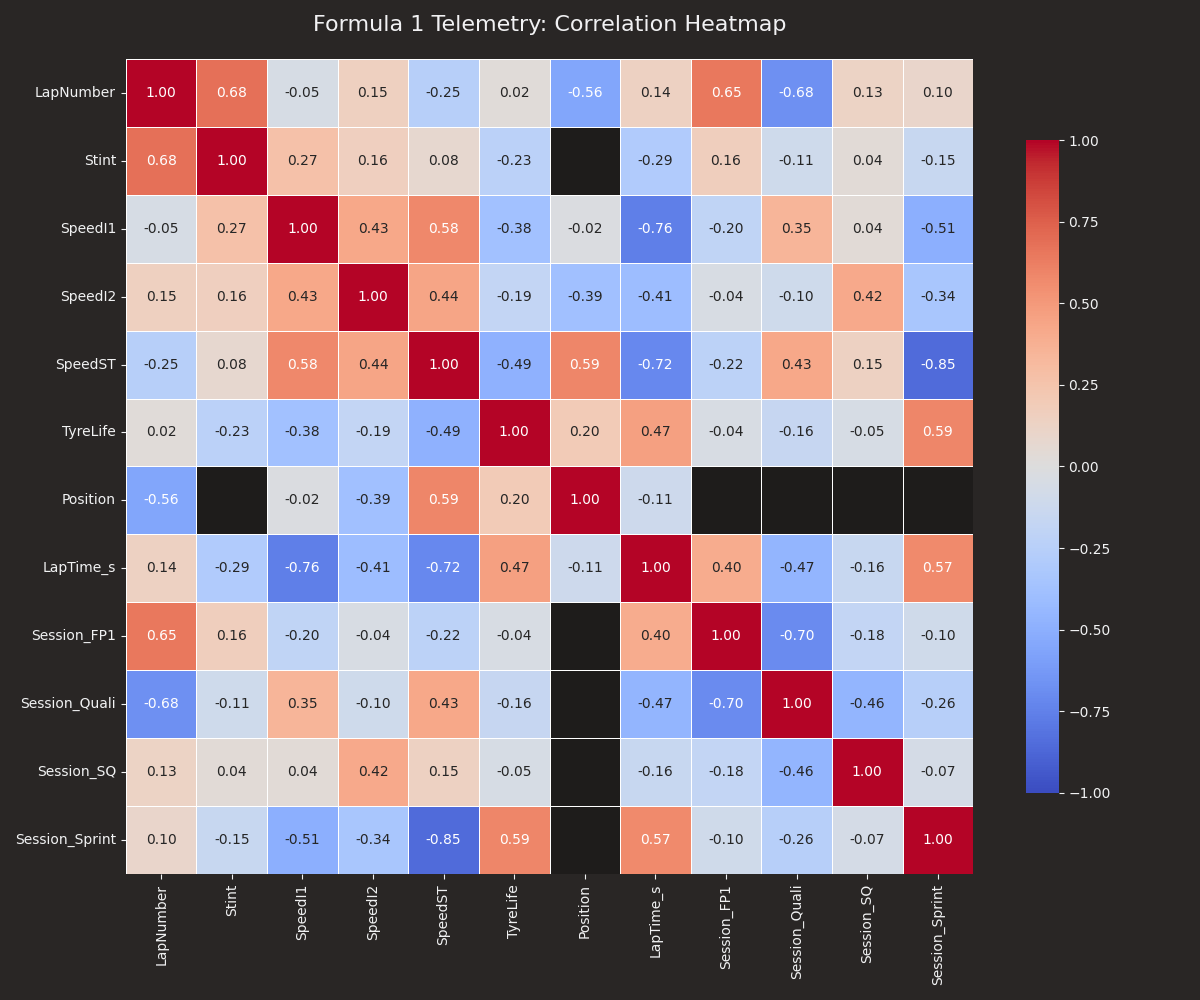


--- Correlations with LapTime_s ---
Session_Sprint    0.571487
TyreLife          0.467140
Session_FP1       0.404143
LapNumber         0.143249
Position         -0.113550
Session_SQ       -0.155698
Stint            -0.289922
SpeedI2          -0.413954
Session_Quali    -0.467428
SpeedST          -0.717124
SpeedI1          -0.758651
Name: LapTime_s, dtype: float64


In [54]:
plot_laptime_correlation_heatmap(soft)

## Summary